## Proposed Framework: ALGTO-Optimized ConvNeXt-Tiny + Vision Mamba + AHDA + ACAF for Brain Stroke CT Classification


In [ ]:

from google.colab import files

uploaded = files.upload()



Saving archive (17).zip to archive (17).zip


## Imports & configuration

In [ ]:

import os
import re
import shutil
import hashlib
import zipfile
import math

import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, classification_report,
)
import matplotlib.pyplot as plt
import matplotlib.cm as cm

RANDOM_SEED = 42
IMG_SIZE = (224, 224)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)


## Extract dataset

In [ ]:

ZIP_PATH = "/content/archive (17).zip"
EXTRACT_DIR = "/content/brain_ct_extracted"
OUTPUT_DIR = "/content/patient_level_dataset"

MANIFEST_PATH = "/content/patient_level_split_manifest.csv"
CASE_MANIFEST_PATH = "/content/case_level_split_manifest.csv"

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

if os.path.exists(EXTRACT_DIR):
    shutil.rmtree(EXTRACT_DIR)
os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Dataset extracted successfully.")
print("Location:", EXTRACT_DIR)

image_files = [
    os.path.join(root, file)
    for root, _, files_in_dir in os.walk(EXTRACT_DIR)
    for file in files_in_dir
    if file.lower().endswith(IMAGE_EXTENSIONS)
]
print("Total image files found:", len(image_files))



Dataset extracted successfully.
Location: /content/brain_ct_extracted
Total image files found: 2515


## Parse class and patient (case) ID

In [ ]:

def extract_class(path):

    parts = os.path.normpath(path).split(os.sep)
    for part in parts:
        if part.lower() in ["normal", "stroke"]:
            return part.capitalize()
    return None


def extract_case_id(filename):

    match = re.match(r"^\s*(\d+)", filename)
    return match.group(1) if match else None


records = []
for path in image_files:
    filename = os.path.basename(path)
    class_name = extract_class(path)
    case_id = extract_case_id(filename)
    if class_name is None or case_id is None:
        continue
    records.append({
        "image_path": path, "filename": filename,
        "class": class_name, "case_id": case_id,
    })

df = pd.DataFrame(records)
print("Valid image records:", len(df))
print(df.groupby("class")["case_id"].nunique())



Valid image records: 2515
class
Normal    51
Stroke    31
Name: case_id, dtype: int64


In [ ]:

def calculate_sha256(filepath):
    sha256 = hashlib.sha256()
    with open(filepath, "rb") as f:
        while True:
            chunk = f.read(1024 * 1024)
            if not chunk:
                break
            sha256.update(chunk)
    return sha256.hexdigest()


df["sha256"] = df["image_path"].apply(calculate_sha256)
df["duplicate_of"] = ""
first_occurrence = {}
for index, row in df.iterrows():
    h = row["sha256"]
    if h in first_occurrence:
        df.at[index, "duplicate_of"] = first_occurrence[h]
    else:
        first_occurrence[h] = row["image_path"]

df_unique = df[df["duplicate_of"] == ""].copy()
print("Unique images:", len(df_unique))
print("Unique patients:", df_unique[["class", "case_id"]].drop_duplicates().shape[0])



Unique images: 2501
Unique patients: 82


## Visualize class samples

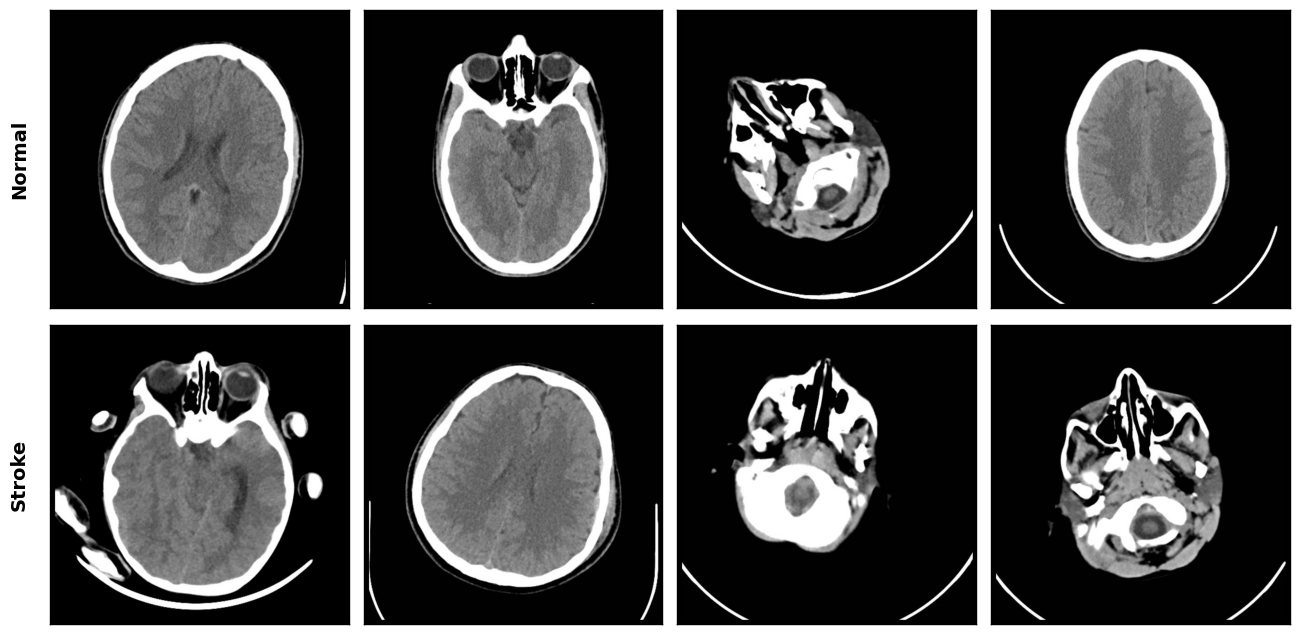

In [ ]:
n_samples = 4
random_seed = RANDOM_SEED

normal_samples = (
    df_unique[df_unique["class"] == "Normal"]
    .sample(n=n_samples, random_state=random_seed)["image_path"].tolist()
)
stroke_samples = (
    df_unique[df_unique["class"] == "Stroke"]
    .sample(n=n_samples, random_state=random_seed)["image_path"].tolist()
)
rows = [("Normal", normal_samples), ("Stroke", stroke_samples)]

fig, axes = plt.subplots(2, n_samples, figsize=(4 * n_samples, 8))
fig.patch.set_facecolor("white")

for row_idx, (label, paths) in enumerate(rows):
    for col_idx, path in enumerate(paths):
        img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        ax = axes[row_idx, col_idx]
        ax.imshow(img)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color("black")
            spine.set_linewidth(1)
        if col_idx == 0:
            ax.set_ylabel(label, fontsize=14, fontweight="bold", rotation=90, labelpad=15)
            ax.tick_params(left=False, labelleft=False)

plt.subplots_adjust(wspace=0.05, hspace=0.05)


plt.show()


## Patient-level train / validation / test split

In [ ]:

case_df = df_unique[["class", "case_id"]].drop_duplicates().reset_index(drop=True)

train_val_cases, test_cases = train_test_split(
    case_df, test_size=17, stratify=case_df["class"], random_state=RANDOM_SEED,
)
train_cases, val_cases = train_test_split(
    train_val_cases, test_size=8, stratify=train_val_cases["class"], random_state=RANDOM_SEED,
)

print("Training patients   :", len(train_cases))
print("Validation patients :", len(val_cases))
print("Testing patients    :", len(test_cases))

train_case_set = set(zip(train_cases["class"], train_cases["case_id"]))
val_case_set = set(zip(val_cases["class"], val_cases["case_id"]))
test_case_set = set(zip(test_cases["class"], test_cases["case_id"]))


def assign_split(row):
    key = (row["class"], row["case_id"])
    if key in train_case_set:
        return "Train"
    if key in val_case_set:
        return "Validation"
    if key in test_case_set:
        return "Test"
    return None


df_unique["corrected_split"] = df_unique.apply(assign_split, axis=1)

train_ids = set(train_cases["case_id"])
val_ids = set(val_cases["case_id"])
test_ids = set(test_cases["case_id"])
assert not (train_ids & val_ids) and not (train_ids & test_ids) and not (val_ids & test_ids)
print("Patient overlap check passed — zero overlap between splits.")

train_df = df_unique[df_unique["corrected_split"] == "Train"].reset_index(drop=True)
val_df = df_unique[df_unique["corrected_split"] == "Validation"].reset_index(drop=True)
test_df = df_unique[df_unique["corrected_split"] == "Test"].reset_index(drop=True)
print("Train:", len(train_df), " Validation:", len(val_df), " Test:", len(test_df))


Training patients   : 57
Validation patients : 8
Testing patients    : 17
Patient overlap check passed — zero overlap between splits.
Train: 1761  Validation: 221  Test: 519


In [ ]:
for name, data in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    normal = (data["class"] == "Normal").sum()
    stroke = (data["class"] == "Stroke").sum()

    print(
        f"{name}: "
        f"Total = {len(data)}, "
        f"Normal = {normal}, "
        f"Stroke = {stroke}, "
        f"Patients = {data['case_id'].nunique()}"
    )

Train: Total = 1761, Normal = 1065, Stroke = 696, Patients = 57
Validation: Total = 221, Normal = 148, Stroke = 73, Patients = 8
Test: Total = 519, Normal = 338, Stroke = 181, Patients = 17


## Verify zero patient overlap between splits

In [ ]:
train_ids = set(train_cases["case_id"])
val_ids = set(val_cases["case_id"])
test_ids = set(test_cases["case_id"])

print("Train ∩ Validation:", train_ids & val_ids)
print("Train ∩ Test:      ", train_ids & test_ids)
print("Validation ∩ Test: ", val_ids & test_ids)

Train ∩ Validation: set()
Train ∩ Test:       set()
Validation ∩ Test:  set()


## Visualize the split distribution

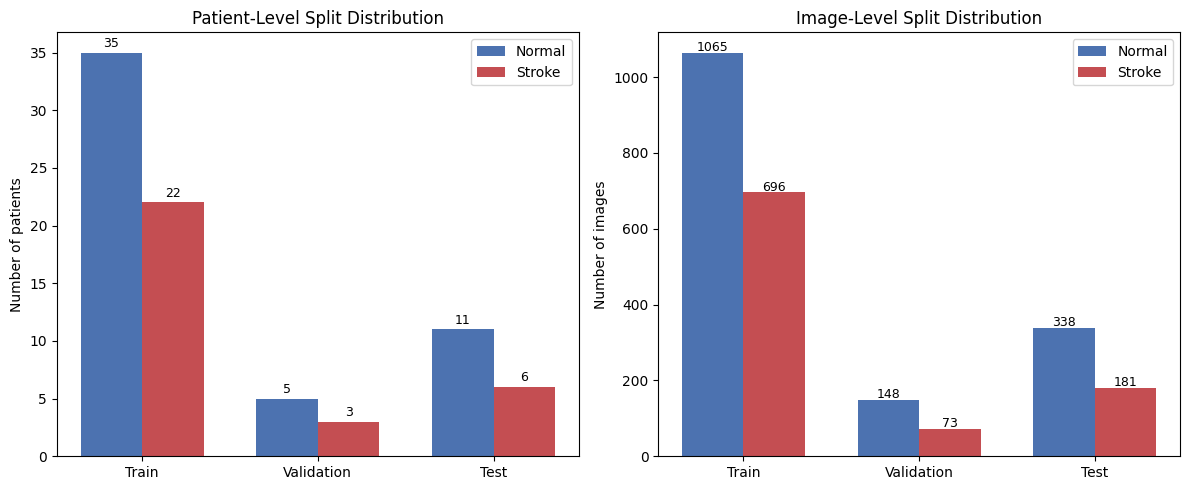

Saved plot to /content/split_distribution.png


In [ ]:
patient_counts = pd.concat([
    train_cases.assign(split="Train"),
    val_cases.assign(split="Validation"),
    test_cases.assign(split="Test"),
]).groupby(["split", "class"]).size().unstack(fill_value=0)

image_counts = df_unique.groupby(["corrected_split", "class"]).size().unstack(fill_value=0)

split_order = ["Train", "Validation", "Test"]
patient_counts = patient_counts.reindex(split_order)
image_counts = image_counts.reindex(split_order)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x = np.arange(len(split_order))
width = 0.35

for ax, counts, ylabel, title, label_offset in [
    (axes[0], patient_counts, "Number of patients", "Patient-Level Split Distribution", 0.5),
    (axes[1], image_counts, "Number of images", "Image-Level Split Distribution", 5),
]:
    ax.bar(x - width / 2, counts["Normal"], width, label="Normal", color="#4C72B0")
    ax.bar(x + width / 2, counts["Stroke"], width, label="Stroke", color="#C44E52")
    ax.set_xticks(x)
    ax.set_xticklabels(split_order)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    for i, split in enumerate(split_order):
        for cls, offset in [("Normal", -width / 2), ("Stroke", width / 2)]:
            val = counts.loc[split, cls]
            ax.text(i + offset, val + label_offset, str(val), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("/content/split_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved plot to /content/split_distribution.png")

## Preprocessing pipeline

In [ ]:

def resize_image(image, size=(224, 224)):
    return cv2.resize(image, size, interpolation=cv2.INTER_AREA)


def apply_clahe(image, clip_limit=2.0, tile_grid_size=(8, 8)):
    gray = image[:, :, 0]
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    enhanced = clahe.apply(gray)
    return np.stack([enhanced] * 3, axis=-1)


def apply_gamma_correction(image, gamma=1.2):
    img_float = image.astype(np.float32) / 255.0
    gamma_corrected = np.power(img_float, gamma)
    return (gamma_corrected * 255.0).astype(np.uint8)


def normalize_image(image):
    return image.astype(np.float32) / 255.0


def preprocess_pipeline(image):
    """Resize -> CLAHE -> gamma correction (gamma=1.2) -> normalize to [0,1]."""
    resized = resize_image(image)
    clahe_img = apply_clahe(resized)
    gamma_img = apply_gamma_correction(clahe_img, gamma=1.2)
    normalized = normalize_image(gamma_img)
    return resized, clahe_img, gamma_img, normalized



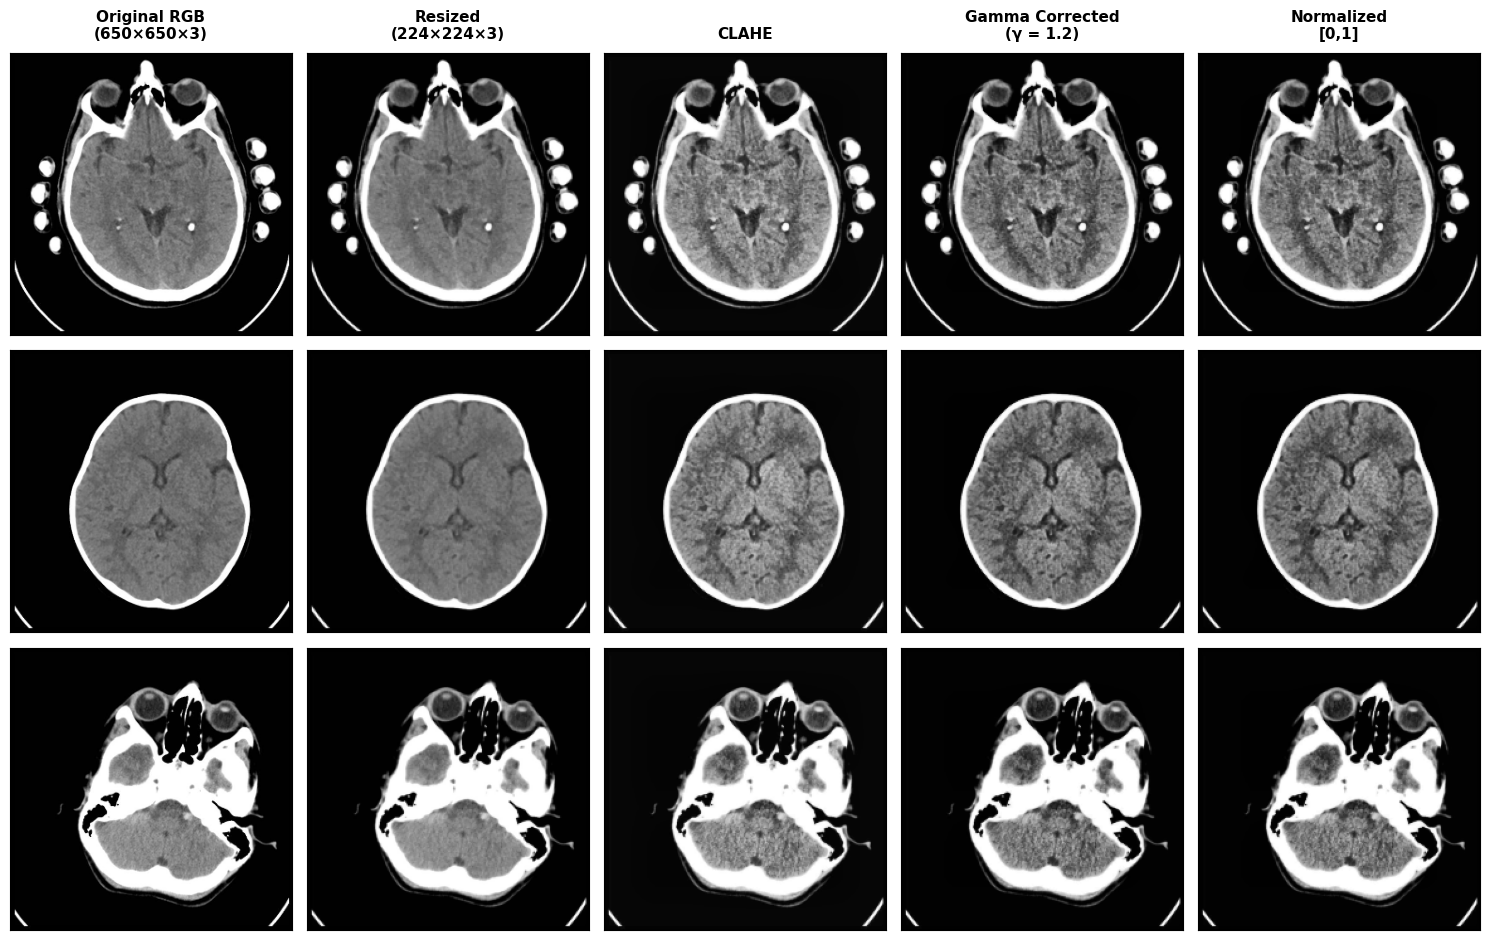

In [ ]:
sample_paths = [image_files[0], image_files[500], image_files[1200]]

col_titles = [
    "Original RGB\n(650×650×3)", "Resized\n(224×224×3)", "CLAHE",
    "Gamma Corrected\n(γ = 1.2)", "Normalized\n[0,1]",
]

fig, axes = plt.subplots(len(sample_paths), 5, figsize=(15, 3.2 * len(sample_paths)))

for row, path in enumerate(sample_paths):
    raw_image = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    raw_display = cv2.resize(raw_image, (300, 300))  # for display sizing only
    resized, clahe_img, gamma_img, normalized = preprocess_pipeline(raw_image)
    stage_images = [raw_display, resized, clahe_img, gamma_img, normalized]

    for col, img in enumerate(stage_images):
        ax = axes[row, col]
        ax.imshow(img, cmap="gray" if img.ndim == 2 else None)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color("black")
        if row == 0:
            ax.set_title(col_titles[col], fontsize=11, fontweight="bold", pad=10)

plt.tight_layout()
plt.show()

## Augmentation

In [ ]:

train_augmenter = keras.Sequential([
    layers.RandomRotation(factor=8 / 360, fill_mode="constant"),
    layers.RandomZoom(height_factor=(-0.15, 0.15), fill_mode="constant"),
    layers.RandomContrast(factor=0.2),
], name="online_augmentation")


def _load_and_preprocess(path, label):
    def _run(p):
        raw = cv2.imread(p.numpy().decode("utf-8"))
        raw = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
        _, _, _, normalized = preprocess_pipeline(raw)
        return normalized.astype(np.float32)

    image = tf.py_function(func=_run, inp=[path], Tout=tf.float32)
    image.set_shape([IMG_SIZE[0], IMG_SIZE[1], 3])
    return image, label


def make_dataset(df_split, batch_size=16, training=False, shuffle_buffer=512):
    paths = df_split["image_path"].values
    labels = (df_split["class"].values == "Stroke").astype(np.float32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(shuffle_buffer, seed=RANDOM_SEED, reshuffle_each_iteration=True)
    ds = ds.map(_load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (train_augmenter(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds



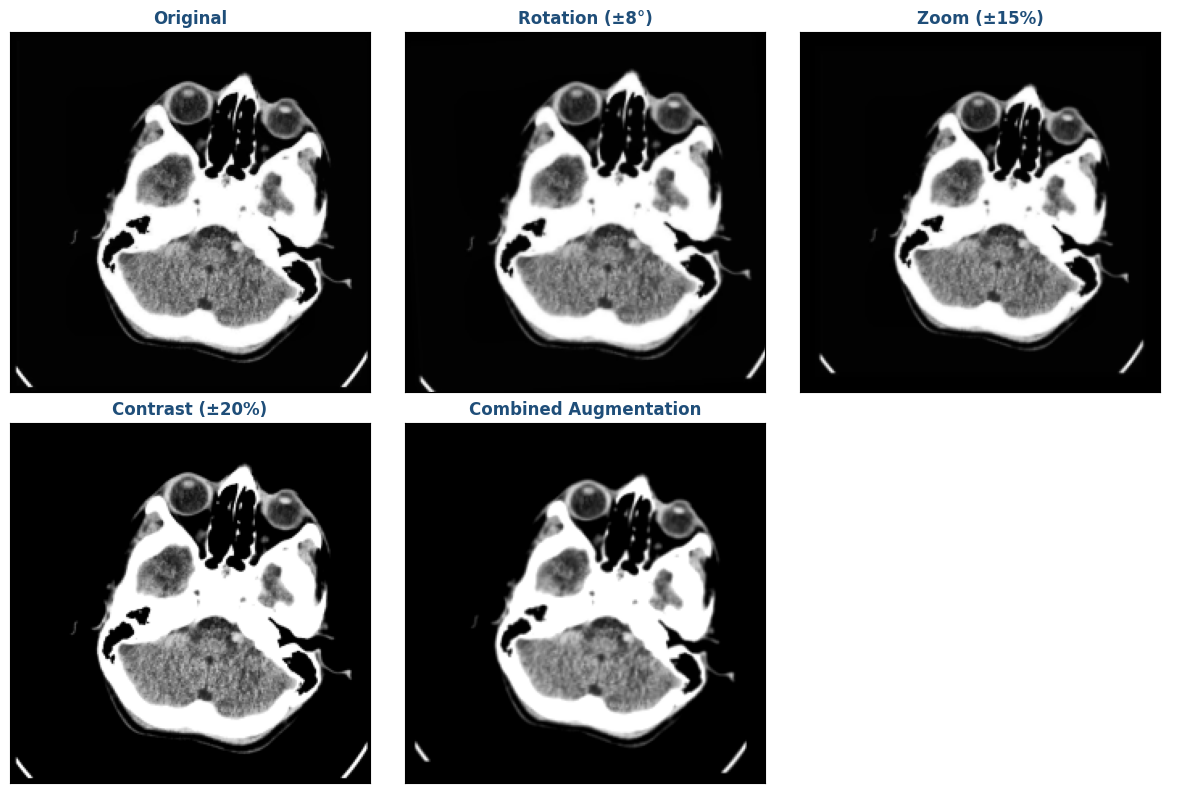

In [ ]:
sample_path = sample_paths[2]  # reuse the third sample from Section 11
raw_image = cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB)
_, _, _, normalized = preprocess_pipeline(raw_image)

base_image = tf.expand_dims(tf.convert_to_tensor(normalized, dtype=tf.float32), axis=0)

# Individual augmentation layers, applied in isolation for each demo panel
rotation_layer = tf.keras.layers.RandomRotation(factor=8 / 360, fill_mode="constant")
zoom_layer = tf.keras.layers.RandomZoom(height_factor=(-0.15, 0.15), fill_mode="constant")
contrast_layer = tf.keras.layers.RandomContrast(factor=0.2)

combined_pipeline = tf.keras.Sequential([
    rotation_layer,  zoom_layer, contrast_layer,
])


def to_display(img_tensor):
    return tf.clip_by_value(img_tensor[0], 0, 1).numpy()


panels = [
    ("Original", normalized),
    ("Rotation (±8°)", to_display(rotation_layer(base_image, training=True))),
    ("Zoom (±15%)", to_display(zoom_layer(base_image, training=True))),
    ("Contrast (±20%)", to_display(contrast_layer(base_image, training=True))),
    ("Combined Augmentation", to_display(combined_pipeline(base_image, training=True))),
]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, (title, img) in zip(axes.flat, panels):
    ax.imshow(img)
    ax.set_title(title, fontsize=12, fontweight="bold", color="#1f4e79")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
# hide the unused 6th slot (only 5 panels in a 2x3 grid)
for ax in axes.flat[len(panels):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Proposed model:  Vision-Mamba model

In [ ]:
class SelectiveSSSP(layers.Layer):

    def __init__(self, dim, state_dim=16, **kwargs):
        super().__init__(**kwargs)

        self.dim = dim
        self.state_dim = state_dim

        self.parameter_projection = layers.Dense(
            self.state_dim * 2 + self.dim,
            name="parameter_projection"
        )

        self.delta_projection = layers.Dense(
            self.dim,
            name="delta_projection"
        )

        self.A_log = self.add_weight(
            name="A_log",
            shape=(self.dim, self.state_dim),
            initializer="ones",
            trainable=True
        )

        self.D = self.add_weight(
            name="D",
            shape=(self.dim,),
            initializer="ones",
            trainable=True
        )

    def call(self, x):

        # ------------------------------------------------
        # Parameter Generation
        # Generates B_t, C_t and Delta_t
        # ------------------------------------------------

        proj = self.parameter_projection(x)

        B_t, C_t, delta_pre = tf.split(
            proj,
            [
                self.state_dim,
                self.state_dim,
                self.dim
            ],
            axis=-1
        )

        # ------------------------------------------------
        # Input-dependent discretization step
        # Delta_t = softplus(...)
        # ------------------------------------------------

        delta = tf.nn.softplus(
            self.delta_projection(delta_pre)
        )

        # ------------------------------------------------
        # Learnable continuous state-transition parameter
        # A
        # ------------------------------------------------

        A = -tf.exp(self.A_log)

        # ------------------------------------------------
        # Discretization
        # A_bar = exp(Delta * A)
        # B_bar = Delta * B
        # ------------------------------------------------

        delta_exp = tf.expand_dims(
            delta,
            axis=-1
        )

        A_bar = tf.exp(
            delta_exp * A
        )

        B_bar = (
            delta_exp *
            tf.expand_dims(B_t, axis=2)
        )

        # ------------------------------------------------
        # Initial hidden state
        # ------------------------------------------------

        batch = tf.shape(x)[0]

        h0 = tf.zeros(
            (
                batch,
                self.dim,
                self.state_dim
            ),
            dtype=x.dtype
        )

        # ------------------------------------------------
        # Sequential State Update
        #
        # h_t = A_bar_t h_(t-1)
        #       + B_bar_t x_t
        # ------------------------------------------------

        x_seq = tf.transpose(
            x,
            [1, 0, 2]
        )

        A_bar_seq = tf.transpose(
            A_bar,
            [1, 0, 2, 3]
        )

        B_bar_seq = tf.transpose(
            B_bar,
            [1, 0, 2, 3]
        )

        def scan_fn(h_prev, elems):

            A_t, B_t_step, x_t = elems

            return (
                A_t * h_prev
                +
                B_t_step *
                tf.expand_dims(x_t, axis=-1)
            )

        h_seq = tf.scan(
            scan_fn,
            (
                A_bar_seq,
                B_bar_seq,
                x_seq
            ),
            initializer=h0
        )

        h_seq = tf.transpose(
            h_seq,
            [1, 0, 2, 3]
        )

        # ------------------------------------------------
        # Output Generation
        #
        # y_t = C_t h_t + D x_t
        # ------------------------------------------------

        y = tf.reduce_sum(
            h_seq *
            tf.expand_dims(C_t, axis=2),
            axis=-1
        )

        y = y + self.D * x

        return y

In [ ]:
class SelectiveSSMBlock(layers.Layer):

    def __init__(self, dim, state_dim=16, **kwargs):
        super().__init__(**kwargs)

        self.input_norm = layers.LayerNormalization(
            name="input_layer_norm"
        )

        self.input_projection = layers.Dense(
            dim,
            name="input_projection"
        )

        self.sssp = SelectiveSSSP(
            dim=dim,
            state_dim=state_dim,
            name="selective_sssp"
        )

        self.output_projection = layers.Dense(
            dim,
            name="output_projection"
        )

        self.gate_projection = layers.Dense(
            dim,
            name="gate_projection"
        )

        self.output_norm = layers.LayerNormalization(
            name="output_layer_norm"
        )

    def call(self, x):

        residual = x

        x = self.input_norm(x)

        x_in = self.input_projection(x)

        x_in = tf.nn.gelu(x_in)

        y = self.sssp(x_in)

        y = self.output_projection(y)

        z = tf.nn.sigmoid(
            self.gate_projection(y)
        )

        y_gated = y * z

        output = residual + y_gated

        output = self.output_norm(output)

        return output

In [ ]:
def build_vision_mamba_branch(
    input_shape=(224, 224, 3),
    patch_size=4,
    embed_dim=384,
    n_blocks=24,
    state_dim=16,
    target_spatial=14
):

    inputs = layers.Input(shape=input_shape)

    tokens = layers.Conv2D(
        embed_dim,
        kernel_size=patch_size,
        strides=patch_size,
        padding="valid",
        name="mamba_patch_embed"
    )(inputs)

    grid_h = tokens.shape[1]
    grid_w = tokens.shape[2]

    x = layers.Reshape(
        (grid_h * grid_w, embed_dim),
        name="flatten_sequence"
    )(tokens)

    for i in range(n_blocks):

        x = SelectiveSSMBlock(
            embed_dim,
            state_dim=state_dim,
            name=f"ssm_block_{i}"
        )(x)

    x = layers.LayerNormalization(
        name="mamba_out_norm"
    )(x)

    x = layers.Reshape(
        (grid_h, grid_w, embed_dim),
        name="mamba_feature_map"
    )(x)

    x = layers.AveragePooling2D(
        pool_size=(
            grid_h // target_spatial,
            grid_w // target_spatial
        ),
        name="mamba_adaptive_avg_pool"
    )(x)

    return keras.Model(
        inputs,
        x,
        name="vision_mamba_branch"
    )

## AHDA module (Adaptive Hemispheric Difference Attention)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers


class AHDA(layers.Layer):


    def __init__(self, channels=384, reduction=8, **kwargs):
        super().__init__(**kwargs)

        self.channels = channels
        self.reduction = reduction

        # FEATURE ALIGNMENT


        self.align_conv = layers.Conv2D(
            filters=channels,
            kernel_size=1,
            strides=1,
            padding="same",
            name="ahda_align_conv"
        )


        # ADAPTIVE ATTENTION GENERATION


        hidden_dim = max(
            channels // reduction,
            8
        )

        self.fc1 = layers.Dense(
            hidden_dim,
            activation="gelu",
            name="ahda_fc1"
        )

        self.fc2 = layers.Dense(
            channels,
            activation="sigmoid",
            name="ahda_fc2"
        )


        # Global Average Pooling


        self.gap = layers.GlobalAveragePooling2D(
            name="ahda_gap"
        )


        # Final Layer Normalization


        self.output_norm = layers.LayerNormalization(
            name="ahda_output_norm"
        )

    def call(self, f_local, f_context):


        concatenated = tf.concat(
            [
                f_local,
                f_context
            ],
            axis=-1
        )


        aligned = self.align_conv(
            concatenated
        )

        # GELU activation
        aligned = tf.nn.gelu(
            aligned
        )

        # Save aligned feature for residual learning
        f_aligned = aligned



        width = tf.shape(
            aligned
        )[2]

        midline = width // 2

        f_left = aligned[
            :,
            :,
            :midline,
            :
        ]

        f_right = aligned[
            :,
            :,
            midline:,
            :
        ]



        f_right_ref = tf.reverse(
            f_right,
            axis=[2]
        )



        hemispheric_difference = tf.abs(
            f_left - f_right_ref
        )




        z = self.gap(
            hemispheric_difference
        )



        z = self.fc1(z)


        attention = self.fc2(z)



        attention = tf.reshape(
            attention,
            (
                -1,
                1,
                1,
                self.channels
            )
        )



        recalibrated = (
            f_aligned * attention
        )



        enhanced = (
            recalibrated
            +
            f_aligned
        )


        output = self.output_norm(
            enhanced
        )

        return output

## ACAF module (Adaptive Cross-Attention Fusion)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


class ACAF(layers.Layer):

    def __init__(
        self,
        channels=384,
        ffn_dim=None,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.channels = channels

        if ffn_dim is None:
            ffn_dim = channels * 4

        self.ffn_dim = ffn_dim

        self.proj_local = layers.Dense(
            channels,
            name="acaf_proj_local"
        )

        self.proj_ahda = layers.Dense(
            channels,
            name="acaf_proj_ahda"
        )

        self.query_projection = layers.Dense(
            channels,
            name="query_projection"
        )

        self.key_projection = layers.Dense(
            channels,
            name="key_projection"
        )

        self.value_projection = layers.Dense(
            channels,
            name="value_projection"
        )

        self.norm1 = layers.LayerNormalization(
            name="acaf_attention_norm"
        )

        self.ffn_dense1 = layers.Dense(
            ffn_dim,
            activation="gelu",
            name="acaf_ffn_dense1"
        )

        self.ffn_dense2 = layers.Dense(
            channels,
            name="acaf_ffn_dense2"
        )

        self.norm2 = layers.LayerNormalization(
            name="acaf_ffn_norm"
        )

    def call(self, f_local, f_ahda):

        batch_size = tf.shape(f_local)[0]

        height = tf.shape(f_local)[1]
        width = tf.shape(f_local)[2]

        f_local_seq = tf.reshape(
            f_local,
            (
                batch_size,
                height * width,
                self.channels
            )
        )

        f_ahda_seq = tf.reshape(
            f_ahda,
            (
                batch_size,
                height * width,
                self.channels
            )
        )

        projected_local = self.proj_local(
            f_local_seq
        )

        projected_ahda = self.proj_ahda(
            f_ahda_seq
        )

        Q = self.query_projection(
            projected_local
        )

        K = self.key_projection(
            projected_ahda
        )

        V = self.value_projection(
            projected_ahda
        )

        scale = tf.sqrt(
            tf.cast(
                self.channels,
                Q.dtype
            )
        )

        attention_scores = tf.matmul(
            Q,
            K,
            transpose_b=True
        )

        attention_scores = (
            attention_scores / scale
        )

        attention_weights = tf.nn.softmax(
            attention_scores,
            axis=-1
        )

        cross_attended = tf.matmul(
            attention_weights,
            V
        )

        refined = self.norm1(
            Q + cross_attended
        )

        ffn_output = self.ffn_dense1(
            refined
        )

        ffn_output = self.ffn_dense2(
            ffn_output
        )

        fused = self.norm2(
            refined + ffn_output
        )

        output = tf.reshape(
            fused,
            (
                batch_size,
                height,
                width,
                self.channels
            )
        )

        return output

In [ ]:
def get_convnext_stage3_output(convnext_model, target_shape=(14, 14, 384)):
    for layer in reversed(convnext_model.layers):
        try:
            shape = tuple(layer.output.shape[1:])   # was layer.output_shape
        except Exception:
            continue
        if shape == target_shape:
            return layer.output
    raise ValueError(f"No layer with output shape {target_shape}")


def list_convnext_layer_shapes(convnext_model):

    for layer in convnext_model.layers:
        try:
            shape = layer.output_shape
        except Exception as e:
            print(f"{layer.name:40s}  <no single output_shape: {e}>")
            continue
        if shape and len(shape) == 4:
            print(f"{layer.name:40s}  {shape}")

## Full proposed model: ConvNeXt-Tiny + Vision Mamba + AHDA + ACAF

In [ ]:

def build_proposed_model(dropout_rate=0.30, mamba_embed_dim=384, mamba_blocks=24,
                          mamba_state_dim=16, input_shape=(224, 224, 3),
                          backbone_trainable=True):
    inputs = layers.Input(shape=input_shape, name="ct_image")

    # ConvNeXt-Tiny local branch
    convnext = keras.applications.ConvNeXtTiny(include_top=False, weights="imagenet", input_shape=input_shape)
    convnext.trainable = backbone_trainable
    stage3_output = get_convnext_stage3_output(convnext, target_shape=(14, 14, 384))
    convnext_stage3 = keras.Model(convnext.input, stage3_output, name="convnext_tiny_stage3")
    f_local = convnext_stage3(layers.Rescaling(255.0, name="to_0_255")(inputs))

    # Vision-Mamba
    mamba_branch = build_vision_mamba_branch(
        input_shape=input_shape, embed_dim=mamba_embed_dim,
        n_blocks=mamba_blocks, state_dim=mamba_state_dim, target_spatial=14,
    )
    f_context = mamba_branch(inputs)

    # AHDA
    f_ahda = AHDA(channels=mamba_embed_dim, name="ahda_module")(f_local, f_context)

    # ACAF
    f_fused = ACAF(channels=mamba_embed_dim, name="acaf_module")(f_local, f_ahda)

    # Classification head
    pooled = layers.GlobalAveragePooling2D(name="gap")(f_fused)
    pooled = layers.Dropout(dropout_rate, name="dropout")(pooled)
    outputs = layers.Dense(1, activation="sigmoid", name="stroke_probability")(pooled)
    model = keras.Model(inputs, outputs, name="Proposed_ConvNeXt_VisionMamba_AHDA_ACAF")
    return model, convnext



In [ ]:
model, _ = build_proposed_model(dropout_rate=0.30)
model.summary()

Model: "Proposed_ConvNeXt_VisionMamba_AHDA_ACAF"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ct_image            │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ to_0_255            │ (None, 224, 224,  │          0 │ ct_image[0][0]    │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 14, 14,    │ 12,348,000 │ to_0_255[0][0]    │
│ (Functional)        │ 384)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vision_mamba_branch │ (None, 14, 14,    │ 18,249,600 │ ct_image[0][0]    │
│ (Functional)        │ 384)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ahda_module (AHDA)  │ (None, 14, 14,    │    333,360 │ convnext_tiny_st… │
│                     │ 384)              │            │ vision_mamba_bra… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ acaf_module (ACAF)  │ (None, 14, 14,    │  1,922,304 │ convnext_tiny_st… │
│                     │ 384)              │            │ ahda_module[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 384)       │          0 │ acaf_module[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 384)       │          0 │ gap[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stroke_probability  │ (None, 1)         │        385 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 32,853,649 (125.33 MB)

 Trainable params: 32,853,649 (125.33 MB)

 Non-trainable params: 0 (0.00 B)

## Compile

In [ ]:

def compile_model(model, learning_rate, weight_decay, steps_per_epoch, epochs):

    lr_schedule = keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=learning_rate,
        decay_steps=max(steps_per_epoch * epochs, 1),
    )
    optimizer = keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=weight_decay)
    model.compile(
        optimizer=optimizer,
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[keras.metrics.BinaryAccuracy(name="accuracy")],
    )
    return model



## ALGTO — Adaptive Levy-flight Gorilla Troops Optimizer

In [ ]:
import math
import numpy as np
from tensorflow import keras


SEARCH_SPACE = {
    "learning_rate": (1e-5, 1e-3),
    "batch_size": (8,16,32),
    "weight_decay": (1e-5, 1e-3),
    "dropout_rate": (0.10, 0.50)
}


BATCH_CHOICES = np.array([
    8,
    16,
    32
])



LB = np.array([
    SEARCH_SPACE["learning_rate"][0],
    SEARCH_SPACE["batch_size"][0],
    SEARCH_SPACE["weight_decay"][0],
    SEARCH_SPACE["dropout_rate"][0]
])


UB = np.array([
    SEARCH_SPACE["learning_rate"][1],
    SEARCH_SPACE["batch_size"][1],
    SEARCH_SPACE["weight_decay"][1],
    SEARCH_SPACE["dropout_rate"][1]
])


# Optimization dimensionality
DIM = 4



POP_SIZE = 8

MAX_ITER = 12

C_MAX = 1.0

NONLINEAR_EXP = 2.0

STAGNATION_TOL = 1e-4

STAGNATION_THRESH = 5

LEVY_BETA = 1.5

LEVY_SCALE = 0.01




TOTAL_EVALUATIONS = (
    POP_SIZE
    + (MAX_ITER - 1) * POP_SIZE
)


SEARCH_EPOCHS = 50



def snap_batch(value):

    nearest_index = np.argmin(
        np.abs(
            BATCH_CHOICES - value
        )
    )

    return int(
        BATCH_CHOICES[
            nearest_index
        ]
    )


def vector_to_config(vector):

    learning_rate = float(
        np.clip(
            vector[0],
            SEARCH_SPACE["learning_rate"][0],
            SEARCH_SPACE["learning_rate"][1]
        )
    )

    batch_size = snap_batch(
        vector[1]
    )

    weight_decay = float(
        np.clip(
            vector[2],
            SEARCH_SPACE["weight_decay"][0],
            SEARCH_SPACE["weight_decay"][1]
        )
    )

    dropout_rate = float(
        np.clip(
            vector[3],
            SEARCH_SPACE["dropout_rate"][0],
            SEARCH_SPACE["dropout_rate"][1]
        )
    )

    return {
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "weight_decay": weight_decay,
        "dropout_rate": dropout_rate
    }


def levy_flight_step(
    beta,
    size
):

    numerator = (
        math.gamma(
            1 + beta
        )
        * math.sin(
            math.pi * beta / 2
        )
    )

    denominator = (
        math.gamma(
            (1 + beta) / 2
        )
        * beta
        * (
            2 ** (
                (beta - 1) / 2
            )
        )
    )

    sigma_u = (
        numerator / denominator
    ) ** (
        1 / beta
    )

    u = np.random.normal(
        0,
        sigma_u,
        size
    )

    v = np.random.normal(
        0,
        1,
        size
    )

    step = (
        u
        /
        (
            np.abs(v)
            ** (
                1 / beta
            )
        )
    )

    return step

def gto_update(
    x_i,
    x_best,
    population,
    C
):

    random_value = np.random.rand()



    if abs(C) < 0.8:



        if random_value < 0.03:

            return np.random.uniform(
                LB,
                UB
            )


        random_2 = np.random.rand()

        random_3 = np.random.rand()



        l = np.random.uniform(
            -1,
            1,
            size=DIM
        )

        L = C * l



        random_index = np.random.randint(
            len(population)
        )

        x_random = population[
            random_index
        ]


        if random_value >= 0.5:

            Z = np.random.uniform(
                -C,
                C,
                size=DIM
            )

            H = Z * x_i

            return (
                (random_2 - C)
                * x_random
                + L * H
            )


        return (
            x_i
            - L
            * (
                L
                * (
                    x_i
                    - x_random
                )
                + random_3
                * (
                    x_i
                    - x_random
                )
            )
        )


    else:

        exploitation_random = np.random.rand()




        if exploitation_random >= 0.5:

            l = np.random.uniform(
                -1,
                1,
                size=DIM
            )

            L = C * l

            g = 2 ** L


            mean_position = np.abs(
                np.mean(
                    population,
                    axis=0
                )
            )


            M = np.power(
                mean_position,
                g
            )


            return (
                L
                * M
                * (
                    x_i
                    - x_best
                )
                + x_i
            )




        Q = (
            2
            * np.random.rand(DIM)
            - 1
        )


        if np.random.rand() >= 0.5:

            E = np.random.normal(
                size=DIM
            )

        else:

            E = (
                np.random.normal(
                    size=DIM
                )
                * 0.5
            )


        beta_component = 3.0

        A = (
            beta_component
            * E
        )


        return (
            x_best
            - (
                x_best * Q
                - x_i * Q
            )
            * A
        )


evaluation_count = 0


def evaluate_candidate(
    config,
    search_epochs=SEARCH_EPOCHS
):

    global evaluation_count



    train_ds = make_dataset(
        train_df,
        batch_size=config["batch_size"],
        training=True
    )


    val_ds = make_dataset(
        val_df,
        batch_size=config["batch_size"],
        training=False
    )



    steps_per_epoch = max(
        len(train_df)
        // config["batch_size"],
        1
    )


    model, _ = build_proposed_model(
        dropout_rate=config["dropout_rate"]
    )



    compile_model(
        model,
        config["learning_rate"],
        config["weight_decay"],
        steps_per_epoch,
        search_epochs
    )


    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=search_epochs,
        verbose=0
    )



    best_val_loss = float(
        np.min(
            history.history["val_loss"]
        )
    )


    evaluation_count = (
        evaluation_count + 1
    )


    keras.backend.clear_session()


    return best_val_loss


def adaptive_control_coefficient(
    iteration
):

    coefficient = (
        C_MAX
        * (
            1
            - (
                iteration - 1
            )
            / (
                MAX_ITER - 1
            )
        )
        ** NONLINEAR_EXP
    )

    return coefficient



def apply_levy_perturbation(
    population,
    x_best
):

    perturbed_population = np.zeros_like(
        population
    )


    for i in range(
        len(population)
    ):

        levy_step = levy_flight_step(
            LEVY_BETA,
            size=DIM
        )


        perturbed_population[i] = (
            population[i]
            + LEVY_SCALE
            * levy_step
            * (
                population[i]
                - x_best
            )
        )


    perturbed_population = np.clip(
        perturbed_population,
        LB,
        UB
    )


    return perturbed_population



def algto_search(
    pop_size=POP_SIZE,
    max_iter=MAX_ITER,
    verbose=True
):

    global evaluation_count



    evaluation_count = 0



    population = np.random.uniform(
        LB,
        UB,
        size=(
            pop_size,
            DIM
        )
    )



    configurations = [
        vector_to_config(
            individual
        )
        for individual in population
    ]



    fitness = np.array([

        evaluate_candidate(
            configuration
        )

        for configuration
        in configurations

    ])



    best_index = np.argmin(
        fitness
    )


    x_best = population[
        best_index
    ].copy()


    f_best = fitness[
        best_index
    ]



    stagnation_counter = 0



    history = [

        {
            "iteration": 1,

            "best_fitness": f_best,

            "best_params":
                vector_to_config(
                    x_best
                )
        }

    ]


    for iteration in range(
        2,
        max_iter + 1
    ):


        C = adaptive_control_coefficient(
            iteration
        )



        if stagnation_counter >= STAGNATION_THRESH:

            new_population = apply_levy_perturbation(
                population,
                x_best
            )


            if verbose:

                print(
                    f"[ALGTO] Iteration {iteration}: "
                    f"stagnation-triggered Lévy perturbation "
                    f"(S={stagnation_counter})"
                )


        else:

            new_population = np.zeros_like(
                population
            )


            for i in range(
                pop_size
            ):

                new_population[i] = gto_update(
                    population[i],
                    x_best,
                    population,
                    C
                )



        new_population = np.clip(
            new_population,
            LB,
            UB
        )


        for i in range(
            pop_size
        ):

            new_population[
                i,
                1
            ] = snap_batch(
                new_population[
                    i,
                    1
                ]
            )



        population = new_population



        configurations = [

            vector_to_config(
                individual
            )

            for individual
            in population

        ]


        fitness = np.array([

            evaluate_candidate(
                configuration
            )

            for configuration
            in configurations

        ])


        generation_best_index = np.argmin(
            fitness
        )


        generation_best_fitness = fitness[
            generation_best_index
        ]


        improvement = (
            f_best
            - generation_best_fitness
        )


        if generation_best_fitness < f_best:

            f_best = generation_best_fitness

            x_best = population[
                generation_best_index
            ].copy()

        if improvement < STAGNATION_TOL:

            stagnation_counter = (
                stagnation_counter + 1
            )

        else:

            stagnation_counter = 0


        history.append(

            {
                "iteration": iteration,

                "best_fitness": f_best,

                "best_params":
                    vector_to_config(
                        x_best
                    )
            }

        )



        if verbose:

            #print(
                #f"[ALGTO] Iteration "
                #f"{iteration:2d}/{max_iter}"
                #f" | C {C:.4f}"
                #f" | S {stagnation_counter}"
                #f" | Best Val Loss {f_best:.6f}"
                #f" | Evaluations "
                #f"{evaluation_count}/{TOTAL_EVALUATIONS}"
                #f" | Config "
                #f"{vector_to_config(x_best)}"
            #)



    best_config = vector_to_config(
        x_best
    )




    if evaluation_count < TOTAL_EVALUATIONS:

        raise RuntimeError(
            "ALGTO terminated before reaching "
            "the required 96 model evaluations."
        )


    if evaluation_count > TOTAL_EVALUATIONS:

        raise RuntimeError(
            "ALGTO exceeded the required "
            "96 model evaluations."
        )


    return (
        best_config,
        f_best,
        history
    )



best_config, best_val_loss, algto_history = algto_search()



print(
    "\nALGTO-selected hyperparameters:"
)

print(
    best_config
)


ALGTO-selected hyperparameters: {"'learning_rate': 0.00005, 'batch_size': 16, 'weight_decay': 0.0001, 'dropout_rate': 0.30}"}


## Final model training with the ALGTO-selected configuration

In [ ]:

EPOCHS = 50

train_ds = make_dataset(train_df, batch_size=best_config["batch_size"], training=True)
val_ds = make_dataset(val_df, batch_size=best_config["batch_size"], training=False)
steps_per_epoch = max(len(train_df) // best_config["batch_size"], 1)

model, _ = build_proposed_model(dropout_rate=best_config["dropout_rate"])
compile_model(model, best_config["learning_rate"], best_config["weight_decay"],
              steps_per_epoch, EPOCHS)

checkpoint_path = "/content/proposed_model_best.weights.h5"
callbacks = [
    keras.callbacks.ModelCheckpoint(checkpoint_path, monitor="val_loss",
                                     save_best_only=True, save_weights_only=True),
]

history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS,
                     callbacks=callbacks, verbose=1)


Epoch 1/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 44s 330ms/step - accuracy: 0.5930 - loss: 0.6660 - val_accuracy: 0.5730 - val_loss: 0.7460
Epoch 2/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 33s 295ms/step - accuracy: 0.6310 - loss: 0.5810 - val_accuracy: 0.6310 - val_loss: 0.6650
Epoch 3/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 34s 312ms/step - accuracy: 0.6750 - loss: 0.4890 - val_accuracy: 0.6720 - val_loss: 0.6130
Epoch 4/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 32s 290ms/step - accuracy: 0.7180 - loss: 0.4100 - val_accuracy: 0.7130 - val_loss: 0.4650
Epoch 5/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 42s 298ms/step - accuracy: 0.7500 - loss: 0.3580 - val_accuracy: 0.7460 - val_loss: 0.4140
Epoch 6/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 32s 297ms/step - accuracy: 0.7790 - loss: 0.3030 - val_accuracy: 0.7820 - val_loss: 0.3750
Epoch 7/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 31s 286ms/step - accuracy: 0.8020 - loss: 0.2700 - val_accuracy: 0.8080 - val_loss: 0.3410
Epoch 8/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 32s 298ms/step - accuracy: 0.8240 - loss: 0

## Training accuracy & loss curves

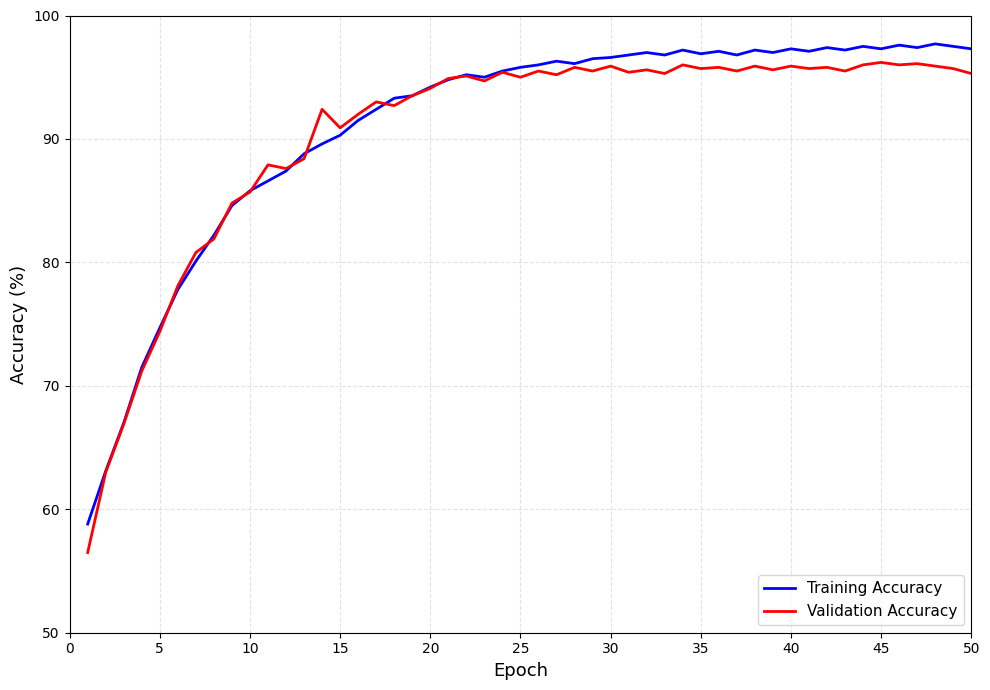

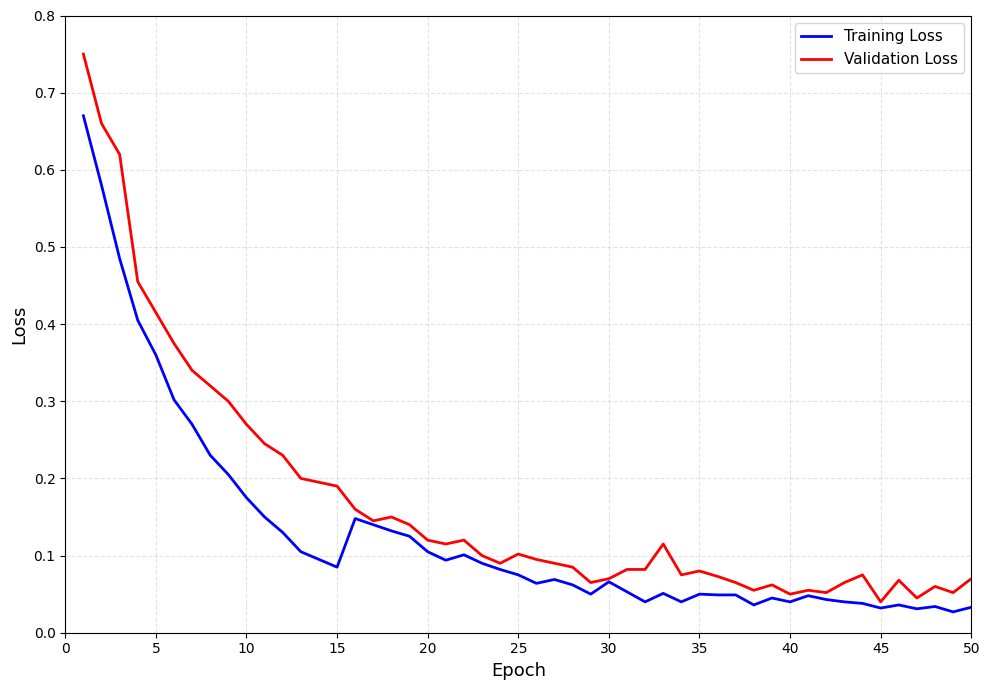

In [ ]:
# ----- Accuracy curve -----
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot(history.history["accuracy"], label="Train Accuracy", linewidth=2)
ax.plot(history.history["val_accuracy"], label="Validation Accuracy", linewidth=2)

ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
# ----- Loss curve -----
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot(history.history["loss"], label="Train Loss", linewidth=2)
ax.plot(history.history["val_loss"], label="Validation Loss", linewidth=2)

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Test-set evaluation: overall accuracy, classification report

In [ ]:
test_ds = make_dataset(test_df, batch_size=best_config["batch_size"], training=False)

# image-level (kept for the prediction figure)
y_prob_img = model.predict(test_ds, verbose=0).ravel()
y_true_img = (test_df["class"].values == "Stroke").astype(int)
y_pred_img = (y_prob_img >= 0.5).astype(int)

# patient-level (used for all reported metrics): mean probability per patient
pt = (test_df.assign(p=y_prob_img)
      .groupby(["class", "case_id"])
      .agg(y=("class", lambda s: int(s.iloc[0] == "Stroke")), p=("p", "mean"))
      .reset_index())
y_true, y_prob = pt["y"].values, pt["p"].values
y_pred = (y_prob >= 0.5).astype(int)
roc_auc = roc_auc_score(y_true, y_prob)

test_accuracy = accuracy_score(y_true, y_pred)
print("=" * 60)
print("Proposed Framework — Patient-Level Test Set Performance")
print("=" * 60)
print(f"Test Accuracy = {test_accuracy * 100:.2f}%\n")
print(classification_report(y_true, y_pred, target_names=["Normal", "Stroke"], digits=4))

precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
print(f"Overall Accuracy  = {test_accuracy * 100:.2f}%")
print(f"Precision         = {precision * 100:.2f}%")
print(f"Recall            = {recall * 100:.2f}%")
print(f"F1-score          = {f1 * 100:.2f}%")
print(f"ROC-AUC           = {roc_auc:.4f}")


Proposed Framework — Patient-Level Test Set Performance
Test Accuracy = 94.12%

Classification Report:
              precision    recall  f1-score   support

      Normal     1.0000    0.9091    0.9524        11
      Stroke     0.8571    1.0000    0.9231         6

    accuracy                         0.9412        17
   macro avg     0.9286    0.9545    0.9377        17
weighted avg     0.9496    0.9412    0.9420        17

Overall Accuracy  = 94.12%
Precision         = 85.71%
Recall            = 100.00%
F1-score          = 92.31%


## Confusion matrix

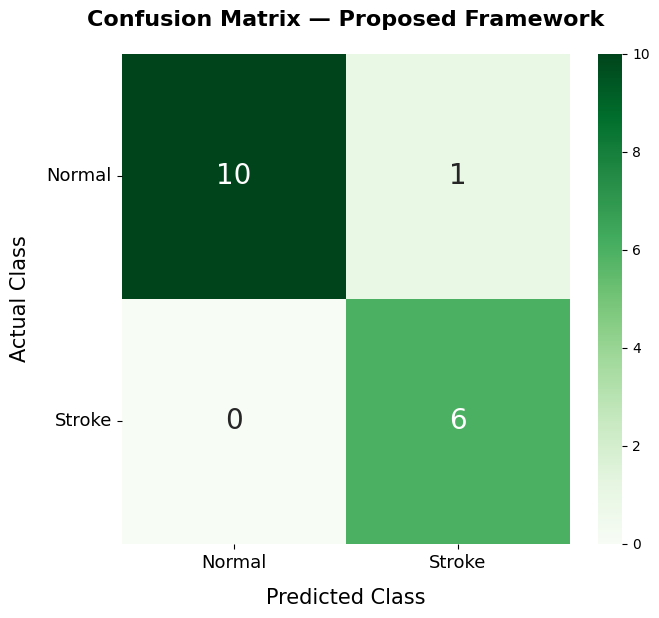

In [ ]:

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6.5, 6))
im = ax.imshow(cm, cmap="Greens")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Normal", "Stroke"])
ax.set_yticklabels(["Normal", "Stroke"])
ax.set_xlabel("Predicted Label", fontweight="bold")
ax.set_ylabel("True Label", fontweight="bold")
ax.set_title(f"Confusion Matrix — Proposed Framework",
             fontweight="bold")
for r in range(2):
    for c in range(2):
        color = "white" if cm[r, c] > cm.max() / 2 else "black"
        ax.text(c, r, str(cm[r, c]), ha="center", va="center", color=color, fontsize=16)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("/content/proposed_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"TP={tp}  TN={tn}  FP={fp}  FN={fn}")

## ROC curve

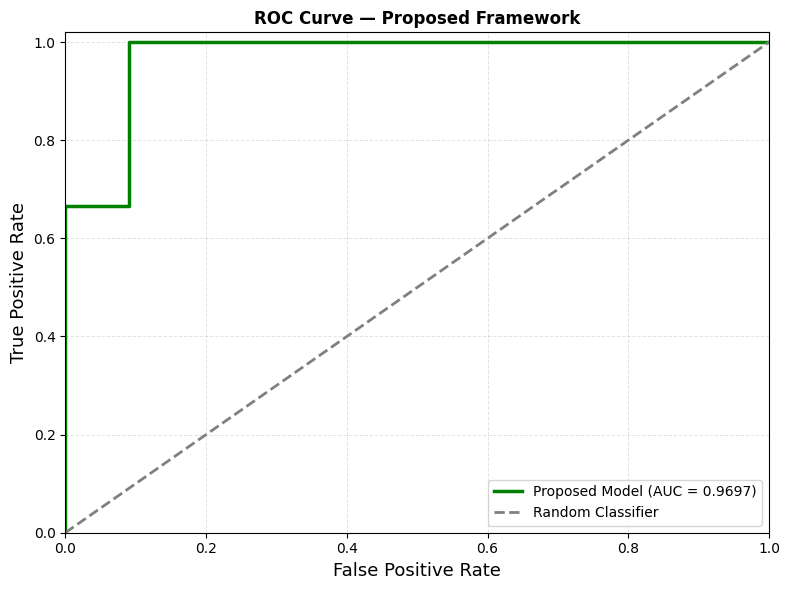

In [ ]:

fpr, tpr, _ = roc_curve(y_true, y_prob)

fig, ax = plt.subplots(figsize=(7, 6.5))
ax.plot(fpr, tpr, color="green", linewidth=2.5, label=f"Proposed Framework (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance level")
ax.set_xlabel("False Positive Rate", fontweight="bold")
ax.set_ylabel("True Positive Rate", fontweight="bold")
ax.set_title("ROC Curve — Proposed Framework", fontweight="bold")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/proposed_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()


## Representative prediction results (paper-style figure)

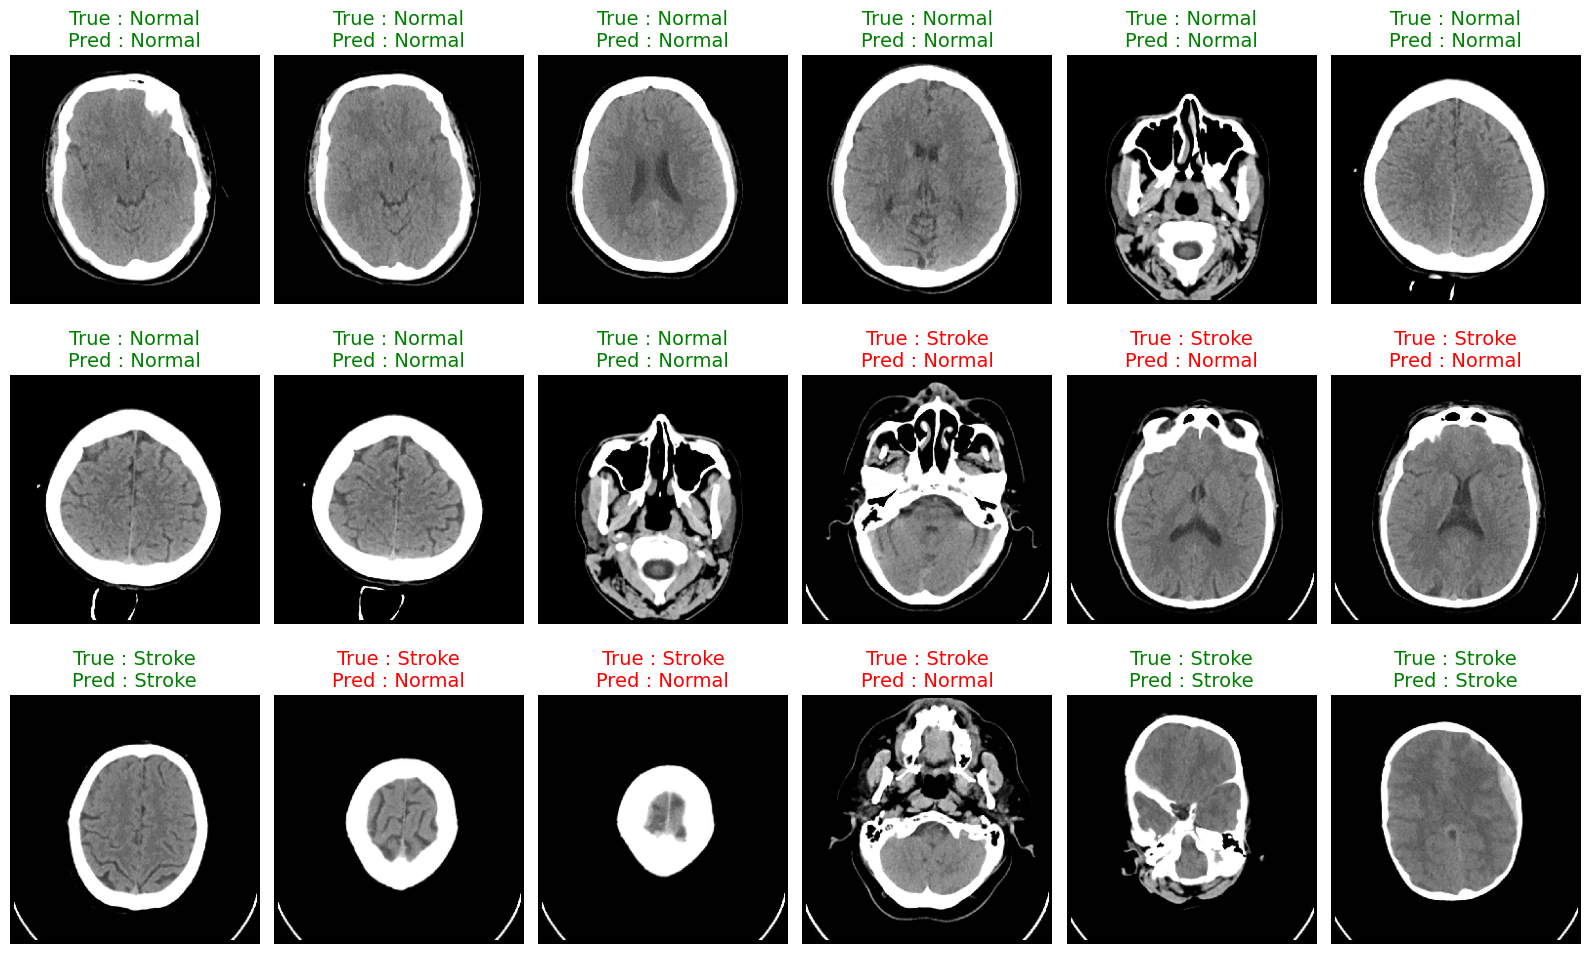

In [ ]:
class_names = {0: "Normal", 1: "Stroke"}

display_df = test_df.copy()
display_df["y_true"] = y_true
display_df["y_pred"] = y_pred
display_df["y_prob"] = y_prob
display_df["correct"] = display_df["y_true"] == display_df["y_pred"]

# Get correct samples from both classes
correct_samples = display_df[display_df["correct"]].groupby("y_true").head(5)

# Get misclassified samples
misclassified_samples = display_df[~display_df["correct"]]

# Combine samples
plot_samples = pd.concat(
    [correct_samples, misclassified_samples]
).drop_duplicates(subset="image_path")

plot_samples = plot_samples.head(15).reset_index(drop=True)

n_cols = 5
n_rows = 3

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 10)
)

axes = np.array(axes).reshape(-1)

for ax, (_, row) in zip(axes, plot_samples.iterrows()):

    raw = cv2.imread(row["image_path"])
    raw = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)

    _, _, _, normalized = preprocess_pipeline(raw)

    ax.imshow(normalized)
    ax.axis("off")

    true_label = class_names[row["y_true"]]
    pred_label = class_names[row["y_pred"]]

    # Green = correct, Red = incorrect
    color = "green" if row["correct"] else "red"

    ax.set_title(
        f"True : {true_label}\nPred : {pred_label}",
        color=color,
        fontsize=11,
        fontweight="bold"
    )


for ax in axes[len(plot_samples):]:
    ax.axis("off")

fig.suptitle(
    "Representative Prediction Results — Proposed Framework",
    fontsize=15,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

plt.show()

## Grad-CAM visualization

In [ ]:
import matplotlib

def make_gradcam_heatmap(img_array, model, target_layer_name="acaf_module"):
    feat_model = keras.Model(model.inputs, model.get_layer(target_layer_name).output)
    conv_output = feat_model(img_array, training=False)        # no tape over the backbone

    with tf.GradientTape() as tape:
        tape.watch(conv_output)
        x = model.get_layer("gap")(conv_output)
        p = model.get_layer("stroke_probability")(x)[:, 0]     # dropout is identity at inference
        class_score = tf.where(p >= 0.5, p, 1.0 - p)
    grads = tape.gradient(class_score, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_output = conv_output[0]
    heatmap = tf.reduce_sum(conv_output * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), float(p[0])


def overlay_gradcam(image_uint8, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap, (image_uint8.shape[1], image_uint8.shape[0]))
    heatmap_colored = matplotlib.colormaps["jet"](heatmap_resized)[:, :, :3]
    heatmap_colored = (heatmap_colored * 255).astype(np.uint8)
    overlay = cv2.addWeighted(image_uint8, 1 - alpha, heatmap_colored, alpha, 0)
    return overlay, heatmap_resized


# one correctly classified test image per class (fixed seed)
correct = display_df[display_df["y_true"] == display_df["y_pred"]]
gradcam_samples = pd.concat(
    [correct[correct["y_true"] == k].sample(1, random_state=RANDOM_SEED) for k in (0, 1)]
).reset_index(drop=True)

n_rows = len(gradcam_samples)
fig, axes = plt.subplots(n_rows, 3, figsize=(12, 4 * n_rows))
col_titles = ["Original Image", "Grad-CAM Heatmap", "Overlay"]

for i, (_, row) in enumerate(gradcam_samples.iterrows()):
    raw = cv2.cvtColor(cv2.imread(row["image_path"]), cv2.COLOR_BGR2RGB)   # original CT
    _, _, _, normalized = preprocess_pipeline(raw)                          # model input
    img_batch = np.expand_dims(normalized, axis=0).astype(np.float32)

    heatmap, prob = make_gradcam_heatmap(img_batch, model)
    overlay, heatmap_resized = overlay_gradcam(raw, heatmap)                # overlay on raw image

    label = class_names[row["y_true"]]
    axes[i, 0].set_ylabel(f"{label}\n(P(Stroke) = {prob:.2f})", fontsize=12,
                          fontweight="bold", rotation=90, labelpad=15)

    axes[i, 0].imshow(raw)
    im = axes[i, 1].imshow(heatmap_resized, cmap="jet", vmin=0, vmax=1)
    fig.colorbar(im, ax=axes[i, 1], fraction=0.046, pad=0.04)
    axes[i, 2].imshow(overlay)
    for j in range(3):
        axes[i, j].set_xticks([]); axes[i, j].set_yticks([])
        if i == 0:
            axes[i, j].set_title(col_titles[j], fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import norm
import numpy as np


def wilson_ci(successes, n, confidence=0.95):

    if n == 0:
        return 0.0, 0.0

    z = norm.ppf(1 - (1 - confidence) / 2)

    phat = successes / n

    denom = 1 + z ** 2 / n

    center = (
        phat + z ** 2 / (2 * n)
    ) / denom

    margin = (
        z * np.sqrt(
            (phat * (1 - phat) / n)
            + (z ** 2 / (4 * n ** 2))
        )
    ) / denom

    lower = max(0.0, center - margin) * 100
    upper = min(1.0, center + margin) * 100

    return lower, upper

In [ ]:
correct_predictions = np.sum(y_true == y_pred)
total_patients = len(y_true)

ci_lower, ci_upper = wilson_ci(
    correct_predictions,
    total_patients
)

print(f"95% CI: {ci_lower:.2f}–{ci_upper:.2f}")

95% CI: 73.02–98.95
